# Problema de clasificare
## Definirea problemei

În această parte a proiectului, este abordată o problemă de clasificare binară. Scopul este construirea unui model de Machine Learning capabil să prezică una dintre cele două clase posibile ale variabilei țintă, pe baza caracteristicilor disponibile în setul de date.

Problema este una de învățare supravegheată, deoarece fiecare observație din setul de date conține atât valorile caracteristicilor de intrare, cât și clasa corectă asociată acesteia.

Obiectivul este analizarea datelor, preprocesarea acestora, antrenarea mai multor modele de clasificare, compararea performanțelor obținute și alegerea celor mai bune modele pentru etapele următoare ale proiectului.

În cadrul clasificării binare, variabila țintă poate lua doar două valori, corespunzătoare celor două clase ale problemei.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import RandomForestClassifier

from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.neighbors import KNeighborsClassifier

from xgboost import XGBClassifier

from catboost import CatBoostClassifier

from interpret.glassbox import ExplainableBoostingClassifier

from sklearn.model_selection import GridSearchCV

from sklearn.model_selection import learning_curve
import numpy as np

import shap

In [4]:
df = pd.read_csv("../data/classification_dataset.csv")

df.head()

,Age,Gender,EducationLevel,ExperienceYears,PreviousCompanies,DistanceFromCompany,InterviewScore,SkillScore,PersonalityScore,RecruitmentStrategy,HiringDecision
0,26,1,2,0,3,26.783828,48,78,91,1,1
1,39,1,4,12,3,25.862694,35,68,80,2,1
2,48,0,2,3,2,9.920805,20,67,13,2,0
3,34,1,2,5,2,6.407751,36,27,70,3,0
4,30,0,1,6,1,43.105343,23,52,85,2,0


In [ ]:
print("Dimensiune dataset:", df.shape)
print("Coloane dataset:")
print(df.columns)

Dimensiune dataset: (1500, 11)
Coloane dataset:
Index(['Age', 'Gender', 'EducationLevel', 'ExperienceYears',
       'PreviousCompanies', 'DistanceFromCompany', 'InterviewScore',
       'SkillScore', 'PersonalityScore', 'RecruitmentStrategy',
       'HiringDecision'],
      dtype='str')


## Descrierea setului de date

Setul de date utilizat pentru problema de clasificare conține 1500 de observații și 11 coloane. Fiecare observație reprezintă un candidat aflat într-un proces de recrutare.

Scopul problemei este prezicerea deciziei de angajare a candidatului, pe baza caracteristicilor disponibile în setul de date.

Variabila țintă este 'HiringDecision', care indică rezultatul procesului de recrutare. Acesta are două clase posibile:

    - '0' = candidatul nu este angajat;
    - '1' = candidatul este angajat.

Caracteristicile de intrare sunt:

    - 'Age' - vârsta candidatului;
    - 'Gender' - genul candidatului, reprezentat numeric;
    - 'EducationLevel' - nivelul de educație;
    - 'ExperienceYears' - numărul de ani de experiență;
    - 'PreviousCompanies' - numărul companiilor anterioare;
    - 'DistanceFromCompany' - distanța față de companie;
    - 'InterviewScore' - scorul obținut la interviu;
    - 'SkillScore' - scorul competențelor;
    - 'PersonalityScore' - scorul de personalitate;
    - 'RecruitmentStrategy' - strategia de recrutare folosită.

Această problemă este relevantă deoarece un model de Machine Learning poate ajuta la analizarea automată a candidaților și la identificarea factorilor care influențează decizia de angajare.

In [6]:
print("Valorile posibile ale variabilei tinta:")
print(df["HiringDecision"].unique())

print("Numarul de exemple pentru fiecare clasa:")
print(df["HiringDecision"].value_counts())

Valorile posibile ale variabilei tinta:
[1 0]
Numarul de exemple pentru fiecare clasa:
HiringDecision
0    1035
1     465
Name: count, dtype: int64


### Interpretarea variabilei țintă

Variabila țintă 'HiringDecision' are două valori posibile: '0' și '1', deci avem clasificare binară.

Clasa '0' reprezintă candidații care nu au fost angajați, iar clasa '1' reprezintă candidații care au fost angajați.

Distribuția claselor este următoarea:

    - clasa '0': 1035 observații;
    - clasa '1': 465 observații.

Se observă că setul de date este dezechilibrat, deoarece clasa 0 apare mult mai des decât clasa 1. Din acest motiv, acuratețea nu va fi suficientă pentru evaluarea modelelor.

## Analiza exploratorie a datelor

În această etapă se analizează structura și calitatea setului de date. Înainte de antrenarea modelelor, este important să verificăm tipurile de date, valorile lipsă și distribuția variabilelor, pentru a decide ce preprocesări sunt necesare.

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  1500 non-null   int64  
 1   Gender               1500 non-null   int64  
 2   EducationLevel       1500 non-null   int64  
 3   ExperienceYears      1500 non-null   int64  
 4   PreviousCompanies    1500 non-null   int64  
 5   DistanceFromCompany  1500 non-null   float64
 6   InterviewScore       1500 non-null   int64  
 7   SkillScore           1500 non-null   int64  
 8   PersonalityScore     1500 non-null   int64  
 9   RecruitmentStrategy  1500 non-null   int64  
 10  HiringDecision       1500 non-null   int64  
dtypes: float64(1), int64(10)
memory usage: 129.0 KB


In [8]:
print("Numarul de valori lipsa pentru fiecare coloana:")
print(df.isnull().sum())

Numarul de valori lipsa pentru fiecare coloana:
Age                    0
Gender                 0
EducationLevel         0
ExperienceYears        0
PreviousCompanies      0
DistanceFromCompany    0
InterviewScore         0
SkillScore             0
PersonalityScore       0
RecruitmentStrategy    0
HiringDecision         0
dtype: int64


### Interpretarea structurii datelor și a valorilor lipsă

Setul de date conține 1500 de observații și 11 coloane. Toate coloanele au 1500 de valori nenule, ceea ce înseamnă că nu există valori lipsă în dataset. Prin urmare, nu este necesară completarea valorilor lipsă sau eliminarea unor observații din acest motiv.

Din punctul de vedere al tipurilor de date, toate variabilele sunt numerice. Majoritatea coloanelor sunt de tip int64, iar coloana 'DistanceFromCompany' este de tip float64.

Acest lucru simplifică etapa de preprocesare, deoarece nu este necesară codificarea variabilelor textuale înainte de antrenarea modelelor.

In [9]:
df.describe()

,Age,Gender,EducationLevel,ExperienceYears,PreviousCompanies,DistanceFromCompany,InterviewScore,SkillScore,PersonalityScore,RecruitmentStrategy,HiringDecision
count,1500.000000,1500.000000,1500.000000,1500.000000,1500.00000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000
mean,35.148667,0.492000,2.188000,7.694000,3.00200,25.505379,50.564000,51.116000,49.387333,1.893333,0.310000
std,9.252728,0.500103,0.862449,4.641414,1.41067,14.567151,28.626215,29.353563,29.353201,0.689642,0.462647
min,20.000000,0.000000,1.000000,0.000000,1.00000,1.031376,0.000000,0.000000,0.000000,1.000000,0.000000
25%,27.000000,0.000000,2.000000,4.000000,2.00000,12.838851,25.000000,25.750000,23.000000,1.000000,0.000000
50%,35.000000,0.000000,2.000000,8.000000,3.00000,25.502239,52.000000,53.000000,49.000000,2.000000,0.000000
75%,43.000000,1.000000,3.000000,12.000000,4.00000,37.737996,75.000000,76.000000,76.000000,2.000000,1.000000
max,50.000000,1.000000,4.000000,15.000000,5.00000,50.992462,100.000000,100.000000,100.000000,3.000000,1.000000


### Interpretarea statisticilor descriptive

Statisticile descriptive oferă o imagine de ansamblu asupra valorilor numerice din setul de date.

Variabila 'Age' are valori între 20 și 50 de ani, ceea ce indică un interval realist pentru candidații analizați. Variabila 'ExperienceYears' are valori între 0 și 15 ani, iar 'PreviousCompanies' variază între 1 și 5, ceea ce sugerează experiențe profesionale diferite între candidați.

Coloana 'DistanceFromCompany' are valori între 1 și 51, indicând distanța candidatului față de companie. Scorurile 'InterviewScore', 'SkillScore' și 'PersonalityScore' sunt cuprinse între 0 și 100, ceea ce este plauzibil pentru scoruri de evaluare.

Variabila 'RecruitmentStrategy' are valori între 1 și 3, ceea ce indică existența a trei strategii de recrutare codificate numeric.

Nu se observă valori imposibile sau extreme evidente în această analiză descriptivă.

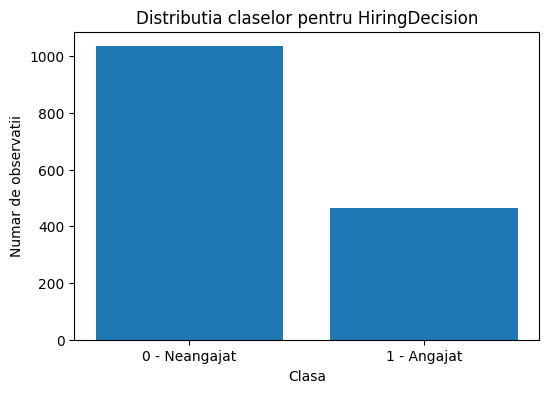

In [93]:
class_counts = df["HiringDecision"].value_counts().sort_index()

plt.figure(figsize=(6,4))
plt.bar(class_counts.index, class_counts.values)
plt.title("Distributia claselor pentru HiringDecision")
plt.xlabel("Clasa")
plt.ylabel("Numar de observatii")
plt.xticks([0, 1], ["0 - Neangajat", "1 - Angajat"])
plt.savefig("../results/eda_hiring_decision.png", bbox_inches="tight", dpi=300)
plt.show()

### Interpretarea distribuției claselor

Graficul arată distribuția observațiilor pentru variabila țintă 'HiringDecision'.

Se observă că există mai multe observații pentru clasa '0', care reprezintă candidații neangajați, decât pentru clasa '1', care reprezintă candidații angajați.

Acest lucru confirmă faptul că setul de date este dezechilibrat. Într-un astfel de caz, acuratețea nu este suficientă pentru evaluarea modelelor, deoarece un model poate obține o acuratețe aparent bună prezicând mai des clasa majoritară.

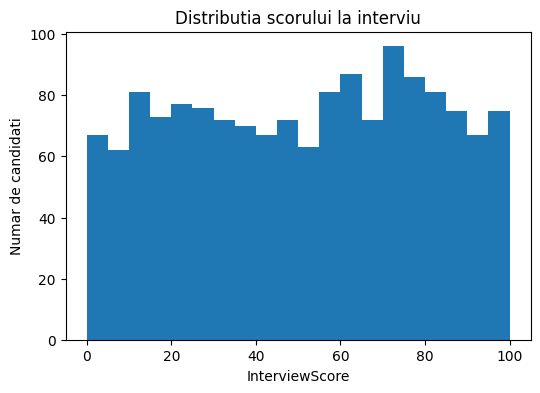

In [94]:
plt.figure(figsize=(6,4))
plt.hist(df["InterviewScore"], bins=20)
plt.title("Distributia scorului la interviu")
plt.xlabel("InterviewScore")
plt.ylabel("Numar de candidati")
plt.savefig("../results/eda_interview_score.png", bbox_inches="tight", dpi=300)
plt.show()

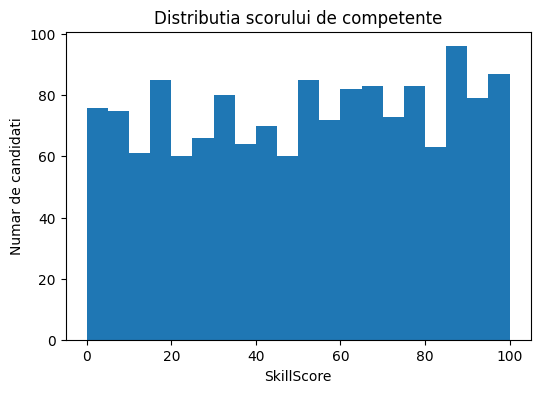

In [95]:
plt.figure(figsize=(6,4))
plt.hist(df["SkillScore"], bins=20)
plt.title("Distributia scorului de competente")
plt.xlabel("SkillScore")
plt.ylabel("Numar de candidati")
plt.savefig("../results/eda_skill_score.png", bbox_inches="tight", dpi=300)
plt.show()

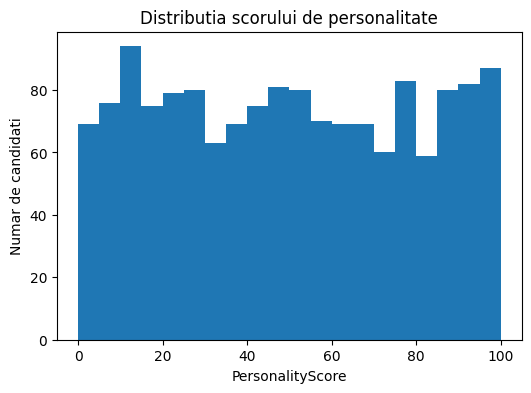

In [96]:
plt.figure(figsize=(6,4))
plt.hist(df["PersonalityScore"], bins=20)
plt.title("Distributia scorului de personalitate")
plt.xlabel("PersonalityScore")
plt.ylabel("Numar de candidati")
plt.savefig("../results/eda_personality_score.png", bbox_inches="tight", dpi=300)
plt.show()

### Interpretarea distribuției scorurilor

Au fost analizate distribuțiile variabilelor 'InterviewScore', 'SkillScore' și 'PersonalityScore', deoarece aceste scoruri pot influența direct decizia de angajare.

Histogramele permit observarea modului în care sunt răspândite valorile scorurilor în setul de date. Aceste grafice ajută la identificarea unor eventuale concentrații de valori, distribuții dezechilibrate sau valori extreme.

În general, scorurile sunt cuprinse între 0 și 100. Nu se observă valori imposibile, precum scoruri negative sau scoruri mai mari de 100.

In [14]:
score_columns = ["InterviewScore", "SkillScore", "PersonalityScore"]
df.groupby("HiringDecision")[score_columns].mean()

,InterviewScore,SkillScore,PersonalityScore
HiringDecision,,,
0,47.762319,47.110145,46.059903
1,56.800000,60.032258,56.793548


### Relația dintre scoruri și decizia de angajare

Pentru a analiza legătura dintre scorurile candidaților și variabila țintă, au fost calculate mediile variabilelor 'InterviewScore', 'SkillScore' și 'PersonalityScore' pentru fiecare clasă a variabilei 'HiringDecision'.

Se observă că, pentru candidații angajați ('HiringDecision' = 1), mediile celor trei scoruri sunt mai mari decât pentru candidații neangajați ('HiringDecision' = 0).

Candidații angajați au un scor mediu la interviu de aproximativ 56.80, comparativ cu 47.76 pentru candidații neangajați. De asemenea, scorul mediu al competențelor este aproximativ 60.03 pentru candidații angajați și 47.11 pentru cei neangajați. Scorul de personalitate este, de asemenea, mai mare pentru candidații angajați.

Acest lucru sugerează că scorurile obținute la interviu, competențe și personalitate pot avea o influență importantă asupra deciziei de angajare și pot fi caracteristici relevante pentru modelele de clasificare.

## Pregătirea datelor pentru antrenare

În această etapă, setul de date este împărțit în variabile de intrare și variabilă țintă.

Variabilele de intrare sunt caracteristicile pe baza cărora modelul va învăța să facă predicții. Variabila țintă este 'HiringDecision', adică valoarea pe care modelul trebuie să o prezică.

Datele vor fi împărțite astfel:

    - 75% pentru antrenare;
    - 25% pentru testare și validare.

In [15]:
X = df.drop("HiringDecision", axis=1)
y = df["HiringDecision"]

print("Dimensiune X:", X.shape)
print("Dimensiune y:", y.shape)

Dimensiune X: (1500, 10)
Dimensiune y: (1500,)


In [16]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

print("Dimensiune X_train:", X_train.shape)
print("Dimensiune X_test:", X_test.shape)
print("Dimensiune y_train:", y_train.shape)
print("Dimensiune y_test:", y_test.shape)


Dimensiune X_train: (1125, 10)
Dimensiune X_test: (375, 10)
Dimensiune y_train: (1125,)
Dimensiune y_test: (375,)


### Interpretarea împărțirii datelor

Se poate observa că setul de antrenare conține 1125 observații, iar setul de testare conține 375 observații.

Parametrul 'stratify=y' a fost folosit pentru a păstra proporția claselor în ambele seturi de date. Acest lucru este important deoarece variabila țintă este dezechilibrată.

Setul de antrenare va fi folosit pentru învățarea modelelor, iar setul de testare va fi folosit pentru evaluarea performanței acestora pe date care nu au fost văzute în timpul antrenării.

## Antrenarea și evaluarea modelelor de bază

În această etapă sunt antrenate modele de clasificare folosind setările implicite ale algoritmilor. Modelele sunt antrenate pe setul de antrenare și evaluate pe setul de testare.

### Model 1: Naive Bayes

Primul model antrenat este Gaussian Naive Bayes. Acest model este potrivit pentru date numerice și se bazează pe probabilități. Modelul estimează probabilitatea ca un candidat să aparțină uneia dintre cele două clase ale variabilei țintă 'HiringDecision'.

In [17]:
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


In [18]:
y_pred_nb = nb_model.predict(X_test)
y_proba_nb = nb_model.predict_proba(X_test)[:, 1]

In [19]:
accuracy_nb = accuracy_score(y_test, y_pred_nb)
precision_nb = precision_score(y_test, y_pred_nb)
recall_nb = recall_score(y_test, y_pred_nb)
f1_nb = f1_score(y_test, y_pred_nb)
roc_auc_nb = roc_auc_score(y_test, y_proba_nb)
conf_matrix_nb = confusion_matrix(y_test, y_pred_nb)

print("Accuracy:", accuracy_nb)
print("Precision:", precision_nb)
print("Recall:", recall_nb)
print("F1-score:", f1_nb)
print("ROC-AUC:", roc_auc_nb)
print("Confusion matrix:")
print(conf_matrix_nb)

Accuracy: 0.848
Precision: 0.8554216867469879
Recall: 0.6120689655172413
F1-score: 0.7135678391959799
ROC-AUC: 0.8837039009452802
Confusion matrix:
[[247  12]
 [ 45  71]]


### Interpretarea rezultatelor pentru Naive Bayes

Modelul Gaussian Naive Bayes a obținut o acuratețe de aproximativ 0.848, ceea ce înseamnă că aproximativ 84.8% dintre predicțiile realizate pe setul de testare au fost corecte.

Precizia este aproximativ 0.855, ceea ce arată că, dintre candidații aleși ca fiind angajați, o proporție mare au fost într-adevăr angajați.

Recall-ul este aproximativ 0.612, ceea ce indică faptul că modelul a identificat corect aproximativ 61.2% dintre candidații care au fost angajați în realitate. Acest scor este mai mic decât precizia, ceea ce sugerează că modelul ratează o parte dintre candidații angajați.

Scorul F1 este aproximativ 0.713 și oferă o măsură de echilibru între precizie și recall.

Valoarea ROC-AUC este aproximativ 0.883, ceea ce indică o capacitate bună a modelului de a separa cele două clase.

Conform matricei de confuzie, modelul a prezis corect 247 de candidați ca fiind neangajați și 71 de candidați ca fiind angajați. Totuși, 12 candidați care în realitate nu au fost angajați au fost clasificați greșit ca angajați, iar 45 de candidați care în realitate au fost angajați au fost clasificați greșit ca neangajați. Acest lucru arată că modelul este mai bun la identificarea candidaților neangajați decât la identificarea candidaților angajați.

### Model 2: Logistic Regression

Al doilea model antrenat este Logistic Regression. Modelul estimează probabilitatea ca o observație să aparțină clasei pozitive. În cazul acestei probleme, clasa pozitivă este 'HiringDecision' = 1, adică situația în care candidatul este angajat.

In [20]:
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [21]:
y_pred_lr = lr_model.predict(X_test)
y_proba_lr = lr_model.predict_proba(X_test)[:, 1]

In [22]:
accuracy_lr = accuracy_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr)
recall_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)
roc_auc_lr = roc_auc_score(y_test, y_proba_lr)
conf_matrix_lr = confusion_matrix(y_test, y_pred_lr)

print("Accuracy:", accuracy_lr)
print("Precision:", precision_lr)
print("Recall:", recall_lr)
print("F1-score:", f1_lr)
print("ROC-AUC:", roc_auc_lr)
print("Confusion matrix:")
print(conf_matrix_lr)

Accuracy: 0.856
Precision: 0.8163265306122449
Recall: 0.6896551724137931
F1-score: 0.7476635514018691
ROC-AUC: 0.8786779390227665
Confusion matrix:
[[241  18]
 [ 36  80]]


### Interpretarea rezultatelor pentru Logistic Regression

Modelul Logistic Regression a obținut o acuratețe de aproximativ 0.856, ceea ce înseamnă că aproximativ 85.6% dintre predicțiile realizate pe setul de testare au fost corecte.

Precizia este aproximativ 0.816. Aceasta arată că, atunci când modelul a prezis că un candidat va fi angajat, predicția a fost corectă în aproximativ 81.6% dintre cazuri.

Recall-ul este aproximativ 0.689, ceea ce arată că modelul a identificat corect aproximativ 69% dintre candidații care au fost angajați în realitate.

Scorul F1 este aproximativ 0.747, fiind mai bun decât cel obținut de Naive Bayes.

Valoarea ROC-AUC este aproximativ 0.878, ceea ce indică o capacitate bună de separare între cele două clase.

Conform matricei de confuzie, modelul a prezis corect 241 de candidați ca fiind neangajați și 80 de candidați ca fiind angajați. Totuși, 18 candidați care în realitate nu au fost angajați au fost clasificați greșit ca angajați, iar 36 de candidați care în realitate au fost angajați au fost clasificați greșit ca neangajați.

### Model 3: Decision Tree

Al treilea model antrenat este Decision Tree. Acest model funcționează prin împărțirea succesivă a datelor în funcție de valorile caracteristicilor, formând o structură asemănătoare unui arbore.

Fiecare nod al arborelui reprezintă o condiție asupra unei caracteristici, iar frunzele arborelui reprezintă clasele prezise. În această problemă, modelul va încerca să învețe reguli care separă candidații angajați de cei neangajați.

In [23]:
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [24]:
y_pred_dt = dt_model.predict(X_test)
y_proba_dt = dt_model.predict_proba(X_test)[:, 1]

In [25]:
accuracy_dt = accuracy_score(y_test, y_pred_dt)
precision_dt = precision_score(y_test, y_pred_dt)
recall_dt = recall_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)
roc_auc_dt = roc_auc_score(y_test, y_proba_dt)
conf_matrix_dt = confusion_matrix(y_test, y_pred_dt)

print("Accuracy:", accuracy_dt)
print("Precision:", precision_dt)
print("Recall:", recall_dt)
print("F1-score:", f1_dt)
print("ROC-AUC:", roc_auc_dt)
print("Confusion matrix:")
print(conf_matrix_dt)

Accuracy: 0.8746666666666667
Precision: 0.822429906542056
Recall: 0.7586206896551724
F1-score: 0.7892376681614349
ROC-AUC: 0.8426308081480495
Confusion matrix:
[[240  19]
 [ 28  88]]


### Interpretarea rezultatelor pentru Decision Tree

Modelul Decision Tree a obținut o acuratețe de aproximativ 0.874, ceea ce înseamnă că aproximativ 87.4% dintre predicțiile realizate pe setul de testare au fost corecte.

Precizia este aproximativ 0.822. Aceasta arată că, atunci când modelul a prezis că un candidat va fi angajat, predicția a fost corectă în aproximativ 82.2% dintre cazuri.

Recall-ul este aproximativ 0.758. Acesta arată că, dintre toți candidații care au fost angajați în realitate, modelul a reușit să identifice corect aproximativ 75.8%.

Scorul F1 este aproximativ 0.789, fiind mai bun decât cel obținut de modelele Naive Bayes și Logistic Regression. Acest lucru indică un echilibru mai bun între precizie și recall.

Valoarea ROC-AUC este aproximativ 0.842. Deși modelul are o acuratețe și un scor F1 bune, valoarea ROC-AUC este mai mică decât la modelele anterioare, ceea ce sugerează că separarea probabilistică a claselor nu este la fel de bună.

Conform matricei de confuzie, modelul a prezis corect 240 de candidați ca fiind neangajați și 88 de candidați ca fiind angajați. Totuși, 19 candidați care în realitate nu au fost angajați au fost clasificați greșit ca angajați, iar 28 de candidați care în realitate au fost angajați au fost clasificați greșit ca neangajați.

Comparativ cu modelele Naive Bayes și Logistic Regression, modelul Decision Tree identifică mai bine candidații care au fost angajați în realitate. Acest lucru se observă prin recall-ul mai mare pentru clasa '1', aproximativ 0.758, față de 0.612 și 0.689.

De asemenea, matricea de confuzie arată că Decision Tree a identificat corect 88 de candidați angajați, față de 71 în cazul Naive Bayes și 80 în cazul Logistic Regression. Prin urmare, până în acest punct, Decision Tree este modelul care recunoaște cel mai bine candidații angajați.

### Model 4: Random Forest

Al patrulea model antrenat este Random Forest. Acest algoritm este format din mai mulți arbori de decizie, iar predicția finală este obținută prin combinarea rezultatelor acestora.

In [26]:
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [27]:
y_pred_rf = rf_model.predict(X_test)
y_proba_rf = rf_model.predict_proba(X_test)[:, 1]

In [28]:
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
roc_auc_rf = roc_auc_score(y_test, y_proba_rf)
conf_matrix_rf = confusion_matrix(y_test, y_pred_rf)

print("Accuracy:", accuracy_rf)
print("Precision:", precision_rf)
print("Recall:", recall_rf)
print("F1-score:", f1_rf)
print("ROC-AUC:", roc_auc_rf)
print("Confusion matrix:")
print(conf_matrix_rf)

Accuracy: 0.9226666666666666
Precision: 0.9578947368421052
Recall: 0.7844827586206896
F1-score: 0.8625592417061612
ROC-AUC: 0.9132272666755424
Confusion matrix:
[[255   4]
 [ 25  91]]


### Interpretarea rezultatelor pentru Random Forest

Modelul Random Forest a obținut cele mai bune rezultate de până acum: acuratețe de aproximativ 0.922, precizie de aproximativ 0.957, recall de aproximativ 0.784, scor F1 de aproximativ 0.862 și ROC-AUC de aproximativ 0.913.

Precizia ridicată arată că modelul greșește foarte rar atunci când prezice că un candidat va fi angajat. Recall-ul indică faptul că modelul identifică aproximativ 78.4% dintre candidații angajați în realitate.

Matricea de confuzie arată că modelul a clasificat corect 255 de candidați neangajați și 91 de candidați angajați. Au existat doar 4 cazuri în care candidați neangajați au fost clasificați greșit ca angajați și 25 de cazuri în care candidați angajați au fost clasificați greșit ca neangajați.

Comparativ cu modelele anterioare, Random Forest are până acum cea mai bună performanță generală, în special prin acuratețe, precizie, scor F1 și ROC-AUC.

### Model 5: Support Vector Machine

Al cincilea model antrenat este Support Vector Machine. Acest model caută o frontieră de separare între cele două clase, astfel încât candidații angajați și neangajați să fie separați cât mai bine.

Deoarece SVM este sensibil la scara valorilor, datele sunt standardizate înainte de antrenarea modelului. Pentru aceasta se folosește un Pipeline, care aplică mai întâi StandardScaler, apoi antrenează modelul SVM.

In [29]:
svm_model = Pipeline([("scaler", StandardScaler()), ("svm", SVC(probability=True, random_state=42))])
svm_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('svm', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'


In [30]:
y_pred_svm = svm_model.predict(X_test)
y_proba_svm = svm_model.predict_proba(X_test)[:, 1]

In [31]:
accuracy_svm = accuracy_score(y_test, y_pred_svm)
precision_svm = precision_score(y_test, y_pred_svm)
recall_svm = recall_score(y_test, y_pred_svm)
f1_svm = f1_score(y_test, y_pred_svm)
roc_auc_svm = roc_auc_score(y_test, y_proba_svm)
conf_matrix_svm = confusion_matrix(y_test, y_pred_svm)

print("Accuracy:", accuracy_svm)
print("Precision:", precision_svm)
print("Recall:", recall_svm)
print("F1-score:", f1_svm)
print("ROC-AUC:", roc_auc_svm)
print("Confusion matrix:")
print(conf_matrix_svm)

Accuracy: 0.8693333333333333
Precision: 0.8681318681318682
Recall: 0.6810344827586207
F1-score: 0.7632850241545893
ROC-AUC: 0.8838037544934098
Confusion matrix:
[[247  12]
 [ 37  79]]


### Interpretarea rezultatelor pentru Support Vector Machine

Modelul Support Vector Machine are o precizie bună, ceea ce înseamnă că predicțiile pentru clasa '1' sunt în mare parte corecte. Totuși, recall-ul este mai redus, deci modelul nu reușește să identifice toți candidații care au fost angajați în realitate.

Din matricea de confuzie se observă că modelul a clasificat corect 247 de candidați neangajați și 79 de candidați angajați. În același timp, 12 candidați neangajați au fost clasificați greșit ca angajați, iar 37 de candidați angajați au fost clasificați greșit ca neangajați.

Comparativ cu Random Forest, SVM obține rezultate mai slabe la acuratețe, recall și scor F1, însă are în continuare o capacitate bună de separare a claselor, indicată de valoarea ROC-AUC.

### Model 6: K-Nearest Neighbors

Al șaselea model antrenat este K-Nearest Neighbors. Acest algoritm clasifică o observație nouă în funcție de clasele celor mai apropiați vecini din setul de antrenare.

Deoarece KNN se bazează pe calculul distanțelor, datele sunt standardizate înainte de antrenare folosind StandardScaler.

In [32]:
knn_model = Pipeline([("scaler", StandardScaler()), ("knn", KNeighborsClassifier())])
knn_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('knn', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30


In [33]:
y_pred_knn = knn_model.predict(X_test)
y_proba_knn = knn_model.predict_proba(X_test)[:, 1]

In [34]:
accuracy_knn = accuracy_score(y_test, y_pred_knn)
precision_knn = precision_score(y_test, y_pred_knn)
recall_knn = recall_score(y_test, y_pred_knn)
f1_knn = f1_score(y_test, y_pred_knn)
roc_auc_knn = roc_auc_score(y_test, y_proba_knn)
conf_matrix_knn = confusion_matrix(y_test, y_pred_knn)

print("Accuracy:", accuracy_knn)
print("Precision:", precision_knn)
print("Recall:", recall_knn)
print("F1-score:", f1_knn)
print("ROC-AUC:", roc_auc_knn)
print("Confusion matrix:")
print(conf_matrix_knn)

Accuracy: 0.8613333333333333
Precision: 0.8555555555555555
Recall: 0.6637931034482759
F1-score: 0.7475728155339806
ROC-AUC: 0.8493376381307416
Confusion matrix:
[[246  13]
 [ 39  77]]


### Interpretarea rezultatelor pentru K-Nearest Neighbors

Rezultatele arată că modelul K-Nearest Neighbors are o performanță acceptabilă, dar nu reușește să identifice la fel de bine candidații angajați ca modelele mai performante. Recall-ul de aproximativ 0.663 indică faptul că modelul identifică aproximativ 66.3% dintre candidații care au fost angajați în realitate.

Din matricea de confuzie se observă că modelul a clasificat corect 246 de candidați neangajați și 77 de candidați angajați. Totuși, 13 candidați neangajați au fost clasificați greșit ca angajați, iar 39 de candidați angajați au fost clasificați greșit ca neangajați.

Comparativ cu Random Forest, modelul KNN are rezultate mai slabe la toate metricile principale, în special la recall și ROC-AUC.

### Model 7: XGBoost

Al șaptelea model antrenat este XGBoost. Acest algoritm face parte din categoria metodelor de boosting și construiește mai mulți arbori de decizie în mod succesiv. Fiecare arbore nou încearcă să corecteze erorile făcute de arborii anteriori.

In [35]:
xgb_model = XGBClassifier(random_state=42, eval_metric="logloss")
xgb_model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [36]:
y_pred_xgb = xgb_model.predict(X_test)
y_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

In [37]:
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
precision_xgb = precision_score(y_test, y_pred_xgb)
recall_xgb = recall_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb)
roc_auc_xgb = roc_auc_score(y_test, y_proba_xgb)
conf_matrix_xgb = confusion_matrix(y_test, y_pred_xgb)

print("Accuracy:", accuracy_xgb)
print("Precision:", precision_xgb)
print("Recall:", recall_xgb)
print("F1-score:", f1_xgb)
print("ROC-AUC:", roc_auc_xgb)
print("Confusion matrix:")
print(conf_matrix_xgb)

Accuracy: 0.9253333333333333
Precision: 0.94
Recall: 0.8103448275862069
F1-score: 0.8703703703703703
ROC-AUC: 0.9196511782718679
Confusion matrix:
[[253   6]
 [ 22  94]]


### Interpretarea rezultatelor pentru XGBoost

Modelul XGBoost a obținut cele mai bune rezultate de până acum, cu o acuratețe de aproximativ 0.925, precizie de aproximativ 0.940, recall de aproximativ 0.810, scor F1 de aproximativ 0.870 și ROC-AUC de aproximativ 0.919.

Rezultatele arată că modelul are o performanță foarte bună atât în identificarea candidaților neangajați, cât și a celor angajați. Recall-ul de aproximativ 0.810 indică faptul că modelul identifică aproximativ 81% dintre candidații care au fost angajați în realitate.

Din matricea de confuzie se observă că modelul a clasificat corect 253 de candidați neangajați și 94 de candidați angajați. Au existat 6 cazuri în care candidați neangajați au fost clasificați greșit ca angajați și 22 de cazuri în care candidați angajați au fost clasificați greșit ca neangajați.

### Model 8: CatBoost

Al optulea model antrenat este CatBoost. Acest algoritm face parte din categoria metodelor de boosting și construiește mai mulți arbori de decizie succesivi.

In [38]:
cat_model = CatBoostClassifier(random_state=42, verbose=0)
cat_model.fit(X_train, y_train)

CatBoostClassifier(random_state=42, verbose=0)

In [39]:
y_pred_cat = cat_model.predict(X_test)
y_proba_cat = cat_model.predict_proba(X_test)[:, 1]

In [40]:
accuracy_cat = accuracy_score(y_test, y_pred_cat)
precision_cat = precision_score(y_test, y_pred_cat)
recall_cat = recall_score(y_test, y_pred_cat)
f1_cat = f1_score(y_test, y_pred_cat)
roc_auc_cat = roc_auc_score(y_test, y_proba_cat)
conf_matrix_cat = confusion_matrix(y_test, y_pred_cat)

print("Accuracy:", accuracy_cat)
print("Precision:", precision_cat)
print("Recall:", recall_cat)
print("F1-score:", f1_cat)
print("ROC-AUC:", roc_auc_cat)
print("Confusion matrix:")
print(conf_matrix_cat)

Accuracy: 0.9413333333333334
Precision: 0.9795918367346939
Recall: 0.8275862068965517
F1-score: 0.897196261682243
ROC-AUC: 0.9160897350552524
Confusion matrix:
[[257   2]
 [ 20  96]]


### Interpretarea rezultatelor pentru CatBoost

CatBoost are cea mai bună performanță dintre modelele testate până acum. Modelul obține o acuratețe de aproximativ 0.941, un scor F1 de aproximativ 0.897 și un ROC-AUC de aproximativ 0.916.

Un rezultat important este precizia foarte mare, de aproximativ 0.979. Acest lucru înseamnă că aproape toate predicțiile de tip 'HiringDecision' = 1 au fost corecte. Recall-ul de aproximativ 0.827 arată că modelul reușește să găsească o parte mare dintre candidații care au fost angajați în realitate.

Matricea de confuzie arată un număr redus de erori. Modelul a clasificat corect 257 de candidați neangajați și 96 de candidați angajați.

Prin comparație cu modelele anterioare, CatBoost este cel mai puternic model la acest moment, mai ales datorită acurateții, preciziei, recall-ului și scorului F1.

### Model 9: Explainable Boosting Machine

Ultimul model analizat este Explainable Boosting Machine. Acest model face parte din categoria modelelor interpretabile și încearcă să combine performanța bună cu posibilitatea de a înțelege mai ușor influența caracteristicilor asupra predicțiilor.

In [41]:
ebm_model = ExplainableBoostingClassifier(random_state=42)
ebm_model.fit(X_train, y_train)

,feature_names,None
,feature_types,None
,max_bins,1024
,max_interaction_bins,64
,interactions,'3x'
,exclude,None
,validation_size,0.15
,outer_bags,14
,inner_bags,0
,learning_rate,0.015
,greedy_ratio,10.0


In [42]:
y_pred_ebm = ebm_model.predict(X_test)
y_proba_ebm = ebm_model.predict_proba(X_test)[:, 1]

In [43]:
accuracy_ebm = accuracy_score(y_test, y_pred_ebm)
precision_ebm = precision_score(y_test, y_pred_ebm)
recall_ebm = recall_score(y_test, y_pred_ebm)
f1_ebm = f1_score(y_test, y_pred_ebm)
roc_auc_ebm = roc_auc_score(y_test, y_proba_ebm)
conf_matrix_ebm = confusion_matrix(y_test, y_pred_ebm)

print("Accuracy:", accuracy_ebm)
print("Precision:", precision_ebm)
print("Recall:", recall_ebm)
print("F1-score:", f1_ebm)
print("ROC-AUC:", roc_auc_ebm)
print("Confusion matrix:")
print(conf_matrix_ebm)

Accuracy: 0.9333333333333333
Precision: 0.9690721649484536
Recall: 0.8103448275862069
F1-score: 0.8826291079812206
ROC-AUC: 0.9124617228065504
Confusion matrix:
[[256   3]
 [ 22  94]]


### Interpretarea rezultatelor pentru Explainable Boosting Machine

Modelul Explainable Boosting Machine a obținut rezultate foarte bune, cu o acuratețe de aproximativ 0.933, precizie de aproximativ 0.969, recall de aproximativ 0.810, scor F1 de aproximativ 0.882 și ROC-AUC de aproximativ 0.912.

Comparativ cu modelele anterioare, EBM are o performanță foarte bună și este apropiat de XGBoost și CatBoost. Avantajul său principal este faptul că este un model mai ușor de interpretat.

## Compararea modelelor de bază

În această etapă sunt comparate modelele de clasificare antrenate anterior, folosind metricile: acuratețe, precizie, recall, scor F1 și ROC-AUC.

Scopul comparației este identificarea celor mai performante modele de bază, care vor fi selectate ulterior pentru etapa de ajustare a hiperparametrilor.

In [44]:
results = pd.DataFrame({
    "Model": [
        "Naive Bayes",
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Support Vector Machine",
        "K-Nearest Neighbors",
        "XGBoost",
        "CatBoost",
        "Explainable Boosting Machine"
    ],
    "Accuracy": [
        accuracy_nb,
        accuracy_lr,
        accuracy_dt,
        accuracy_rf,
        accuracy_svm,
        accuracy_knn,
        accuracy_xgb,
        accuracy_cat,
        accuracy_ebm
    ],
    "Precision": [
        precision_nb,
        precision_lr,
        precision_dt,
        precision_rf,
        precision_svm,
        precision_knn,
        precision_xgb, 
        precision_cat, 
        precision_ebm
    ],
    "Recall": [
        recall_nb, 
        recall_lr, 
        recall_dt, 
        recall_rf, 
        recall_svm, 
        recall_knn, 
        recall_xgb, 
        recall_cat, 
        recall_ebm
    ],
    "F1-score": [
        f1_nb, 
        f1_lr, 
        f1_dt, 
        f1_rf, 
        f1_svm,
        f1_knn, 
        f1_xgb, 
        f1_cat, 
        f1_ebm
    ],
    "ROC-AUC": [
        roc_auc_nb, 
        roc_auc_lr, 
        roc_auc_dt, 
        roc_auc_rf, 
        roc_auc_svm,
        roc_auc_knn,
        roc_auc_xgb,
        roc_auc_cat,
        roc_auc_ebm
    ]
})

results

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Naive Bayes,0.848000,0.855422,0.612069,0.713568,0.883704
1,Logistic Regression,0.856000,0.816327,0.689655,0.747664,0.878678
2,Decision Tree,0.874667,0.822430,0.758621,0.789238,0.842631
3,Random Forest,0.922667,0.957895,0.784483,0.862559,0.913227
4,Support Vector Machine,0.869333,0.868132,0.681034,0.763285,0.883804
5,K-Nearest Neighbors,0.861333,0.855556,0.663793,0.747573,0.849338
6,XGBoost,0.925333,0.940000,0.810345,0.870370,0.919651
7,CatBoost,0.941333,0.979592,0.827586,0.897196,0.916090
8,Explainable Boosting Machine,0.933333,0.969072,0.810345,0.882629,0.912462


In [45]:
results_sorted = results.sort_values(by="F1-score", ascending=False)
results_sorted

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
7,CatBoost,0.941333,0.979592,0.827586,0.897196,0.916090
8,Explainable Boosting Machine,0.933333,0.969072,0.810345,0.882629,0.912462
6,XGBoost,0.925333,0.940000,0.810345,0.870370,0.919651
3,Random Forest,0.922667,0.957895,0.784483,0.862559,0.913227
2,Decision Tree,0.874667,0.822430,0.758621,0.789238,0.842631
4,Support Vector Machine,0.869333,0.868132,0.681034,0.763285,0.883804
1,Logistic Regression,0.856000,0.816327,0.689655,0.747664,0.878678
5,K-Nearest Neighbors,0.861333,0.855556,0.663793,0.747573,0.849338
0,Naive Bayes,0.848000,0.855422,0.612069,0.713568,0.883704


In [46]:
top_models = results_sorted.head(5)
top_models

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
7,CatBoost,0.941333,0.979592,0.827586,0.897196,0.916090
8,Explainable Boosting Machine,0.933333,0.969072,0.810345,0.882629,0.912462
6,XGBoost,0.925333,0.940000,0.810345,0.870370,0.919651
3,Random Forest,0.922667,0.957895,0.784483,0.862559,0.913227
2,Decision Tree,0.874667,0.822430,0.758621,0.789238,0.842631


### Interpretarea comparației modelelor de bază

Pentru alegerea celor mai bune modele, s-a folosit în principal scorul F1, deoarece setul de date este dezechilibrat. Scorul F1 este potrivit în acest caz deoarece combină precizia și recall-ul într-o singură valoare.

Cele mai bune 5 modele de bază sunt:

1. CatBoost
2. Explainable Boosting Machine
3. XGBoost
4. Random Forest
5. Decision Tree

Dintre acestea, CatBoost a obținut cea mai bună performanță generală, având cel mai mare scor F1 și cea mai bună acuratețe.

## Ajustarea hiperparametrilor

Pentru ajustarea hiperparametrilor se folosește GridSearchCV, care testează mai multe combinații de valori pentru hiperparametri și selectează combinația cu cea mai bună performanță.

Scopul acestei etape este îmbunătățirea performanței modelelor și alegerea celui mai bun algoritm după optimizare.

Deoarece există risc de overfitting, modelele optimizate vor fi evaluate atât pe setul de antrenare, cât și pe setul de testare.

### Ajustarea hiperparametrilor pentru Decision Tree

Primul model optimizat este Decision Tree. Pentru acest model vor fi testați hiperparametrii care controlează complexitatea arborelui.

Hiperparametrii analizați sunt:

    - 'max_depth' – adâncimea maximă a arborelui;
    - 'min_samples_split' – numărul minim de observații necesare pentru a împărți un nod;
    - 'min_samples_leaf' – numărul minim de observații care trebuie să existe într-o frunză.

Aceste valori sunt importante deoarece un arbore prea adânc poate învăța prea bine datele de antrenare și poate produce overfitting.

In [47]:
dt_param_grid = {
    "max_depth": [3, 5, 7, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

dt_grid = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=dt_param_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1
)

dt_grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [3, 5, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 :

In [48]:
print("Cei mai buni hiperparametri:")
print(dt_grid.best_params_)

print("Cel mai bun scor F1:")
print(dt_grid.best_score_)

Cei mai buni hiperparametri:
{'max_depth': 7, 'min_samples_leaf': 4, 'min_samples_split': 10}
Cel mai bun scor F1:
0.8603691623673384


### Interpretarea ajustării hiperparametrilor pentru Decision Tree

GridSearchCV testează mai multe combinații de hiperparametri și o alege pe cea cu cel mai bun rezultat. În acest caz, criteriul de selecție a fost scorul F1.

În cod, 'param_grid' conține valorile posibile testate pentru fiecare hiperparametru. Au fost analizați 'max_depth', 'min_samples_split' și 'min_samples_leaf', deoarece aceștia controlează complexitatea arborelui și pot influența riscul de overfitting.

Parametrul cv=5 indică folosirea validării încrucișate cu 5 împărțiri, iar n_jobs=-1 permite folosirea tuturor resurselor disponibile pentru rularea mai rapidă a căutării.

Cea mai bună combinație găsită a fost:

    - 'max_depth' = 7
    - 'min_samples_leaf' = 4
    - 'min_samples_split' = 10

Cel mai bun scor F1 obținut în cross-validation a fost aproximativ 0.860.

In [49]:
best_dt_model = dt_grid.best_estimator_

y_train_pred_dt = best_dt_model.predict(X_train)
y_test_pred_dt = best_dt_model.predict(X_test)

train_f1_dt = f1_score(y_train, y_train_pred_dt)
test_f1_dt = f1_score(y_test, y_test_pred_dt)

print("F1-score pe train:", train_f1_dt)
print("F1-score pe test:", test_f1_dt)

F1-score pe train: 0.9269746646795827
F1-score pe test: 0.8173076923076923


### Verificare overfitting pentru Decision Tree optimizat

Modelul Decision Tree optimizat a obținut un scor F1 de aproximativ 0.926 pe setul de antrenare și aproximativ 0.817 pe setul de testare.

Diferența dintre cele două valori este de aproximativ 0.11, ceea ce indică un posibil overfitting. Modelul are performanță mai bună pe datele de antrenare decât pe datele de testare.

Totuși, scorul F1 pe test este mai bun decât cel obținut de varianta de bază a modelului Decision Tree, deci ajustarea hiperparametrilor a îmbunătățit performanța.

In [50]:
y_test_proba_dt = best_dt_model.predict_proba(X_test)[:, 1]

accuracy_dt_h = accuracy_score(y_test, y_test_pred_dt)
precision_dt_h = precision_score(y_test, y_test_pred_dt)
recall_dt_h = recall_score(y_test, y_test_pred_dt)
f1_dt_h = f1_score(y_test, y_test_pred_dt)
roc_auc_dt_h = roc_auc_score(y_test, y_test_proba_dt)
conf_matrix_dt_h = confusion_matrix(y_test, y_test_pred_dt)

print("Accuracy:", accuracy_dt_h)
print("Precision:", precision_dt_h)
print("Recall:", recall_dt_h)
print("F1-score:", f1_dt_h)
print("ROC-AUC:", roc_auc_dt_h)
print("Confusion matrix:")
print(conf_matrix_dt_h)

Accuracy: 0.8986666666666666
Precision: 0.9239130434782609
Recall: 0.7327586206896551
F1-score: 0.8173076923076923
ROC-AUC: 0.8667121555052589
Confusion matrix:
[[252   7]
 [ 31  85]]


### Rezultatele pentru Decision Tree optimizat

Față de varianta de bază, performanța modelului s-a îmbunătățit. Scorul F1 a crescut de la aproximativ 0.789 la aproximativ 0.817, iar acuratețea a crescut de la aproximativ 0.874 la aproximativ 0.898.

### Ajustarea hiperparametrilor pentru Random Forest

Al doilea model optimizat este Random Forest. Acest model este format din mai mulți arbori de decizie, iar performanța sa depinde de hiperparametri precum numărul de arbori și complexitatea fiecărui arbore.

In [51]:
rf_param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [5, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

rf_grid = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=rf_param_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [5, 10, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], 'n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter 

In [52]:
print("Cei mai buni hiperparametri:")
print(rf_grid.best_params_)

print("Cel mai bun scor F1:")
print(rf_grid.best_score_)

Cei mai buni hiperparametri:
{'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}
Cel mai bun scor F1:
0.8783276634506348


### Interpretarea ajustării hiperparametrilor pentru Random Forest

Au fost analizați hiperparametrii 'n_estimators', 'max_depth', 'min_samples_split' și 'min_samples_leaf'. Aceștia controlează numărul de arbori din model și complexitatea fiecărui arbore.

Cea mai bună combinație găsită a fost:

    - 'n_estimators' = 200
    - 'max_depth' = 10
    - 'min_samples_leaf' = 1
    - 'min_samples_split' = 5

Cel mai bun scor F1 obținut în cross-validation a fost aproximativ 0.878.

In [53]:
best_rf_model = rf_grid.best_estimator_

y_train_pred_rf = best_rf_model.predict(X_train)
y_test_pred_rf = best_rf_model.predict(X_test)

train_f1_rf = f1_score(y_train, y_train_pred_rf)
test_f1_rf = f1_score(y_test, y_test_pred_rf)

print("F1-score pe train:", train_f1_rf)
print("F1-score pe test", test_f1_rf)

F1-score pe train: 0.9618768328445748
F1-score pe test 0.8732394366197183


### Verificare overfitting pentru Random Forest optimizat

Modelul Random Forest optimizat a obținut un scor F1 de aproximativ 0.961 pe setul de antrenare și aproximativ 0.873 pe setul de testare.

Scorul pe antrenare este mai mare decât scorul pe testare, ceea ce indică un posibil overfitting. Totuși, diferența dintre cele două valori este mai mică decât în cazul modelului Decision Tree optimizat, ceea ce sugerează o generalizare mai bună.

In [54]:
y_test_proba_rf = best_rf_model.predict_proba(X_test)[:, 1]

accuracy_rf_h = accuracy_score(y_test, y_test_pred_rf)
precision_rf_h = precision_score(y_test, y_test_pred_rf)
recall_rf_h = recall_score(y_test, y_test_pred_rf)
f1_rf_h = f1_score(y_test, y_test_pred_rf)
roc_auc_rf_h = roc_auc_score(y_test, y_test_proba_rf)
conf_matrix_rf_h = confusion_matrix(y_test, y_test_pred_rf)

print("Accuracy:", accuracy_rf_h)
print("Precision:", precision_rf_h)
print("Recall:", recall_rf_h)
print("F1-score:", f1_rf_h)
print("ROC-AUC:", roc_auc_rf_h)
print("Confusion matrix:")
print(conf_matrix_rf_h)

Accuracy: 0.928
Precision: 0.9587628865979382
Recall: 0.8017241379310345
F1-score: 0.8732394366197183
ROC-AUC: 0.9127612834509387
Confusion matrix:
[[255   4]
 [ 23  93]]


### Rezultatele pentru Random Forest optimizat

Față de varianta de bază, performanța modelului s-a îmbunătățit ușor. Scorul F1 a crescut de la aproximativ 0.862 la aproximativ 0.873, iar recall-ul a crescut de la aproximativ 0.784 la aproximativ 0.801.

### Ajustarea hiperparametrilor pentru XGBoost

Al treilea model optimizat este XGBoost. Acest model construiește arbori de decizie succesivi, fiecare arbore încercând să corecteze erorile modelelor anterioare. 

Hiperparametrii aleși controlează numărul de arbori, adâncimea acestora și viteza de învățare a modelului.

In [55]:
xgb_param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.1],
    "subsample": [0.8, 1.0]
}

xgb_grid = GridSearchCV(
    estimator=XGBClassifier(random_state=42, eval_metric="logloss"),
    param_grid=xgb_param_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1
)

xgb_grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.01, 0.1], 'max_depth': [3, 5, ...], 'n_estimators': [100, 200], 'subsample': [0.8, 1.0]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate i

In [56]:
print("Cei mai buni hiperparametri:")
print(xgb_grid.best_params_)

print("Cel mai bun scor F1:")
print(xgb_grid.best_score_)

Cei mai buni hiperparametri:
{'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 1.0}
Cel mai bun scor F1:
0.8879210073741529


### Interpretarea ajustării hiperparametrilor pentru XGBoost

Au fost testați hiperparametrii 'n_estimators', 'max_depth', 'learning_rate' și 'subsample'. Aceștia controlează numărul de arbori, adâncimea arborilor, viteza de învățare și proporția de date folosită în timpul antrenării.

Cea mai bună combinație găsită a fost:

    - 'learning_rate' = 0.1
    - 'max_depth' = 3
    - 'n_estimators' = 100
    - 'subsample' = 1.0

Cel mai bun scor F1 obținut în cross-validation a fost aproximativ 0.887.

In [57]:
best_xgb_model = xgb_grid.best_estimator_

y_train_pred_xgb = best_xgb_model.predict(X_train)
y_test_pred_xgb = best_xgb_model.predict(X_test)

train_f1_xgb = f1_score(y_train, y_train_pred_xgb)
test_f1_xgb = f1_score(y_test, y_test_pred_xgb)

print("F1-score pe train:", train_f1_xgb)
print("F1-score pe test:", test_f1_xgb)

F1-score pe train: 0.9501466275659824
F1-score pe test: 0.8744186046511628


### Verificare overfitting pentru XGBoost

Modelul XGBoost optimizat a obținut un scor F1 de aproximativ 0.950 pe setul de antrenare și aproximativ 0.874 pe setul de testare.

Comparativ cu Decision Tree optimizat, diferența dintre train și test este mai mică, ceea ce sugerează o generalizare mai bună.

In [58]:
y_test_proba_xgb = best_xgb_model.predict_proba(X_test)[:, 1]

accuracy_xgb_h = accuracy_score(y_test, y_test_pred_xgb)
precision_xgb_h = precision_score(y_test, y_test_pred_xgb)
recall_xgb_h = recall_score(y_test, y_test_pred_xgb)
f1_xgb_h = f1_score(y_test, y_test_pred_xgb)
roc_auc_xgb_h = roc_auc_score(y_test, y_test_proba_xgb)
conf_matrix_xgb_h = confusion_matrix(y_test, y_test_pred_xgb)

print("Accuracy:", accuracy_xgb_h)
print("Precision:", precision_xgb_h)
print("Recall:", recall_xgb_h)
print("F1-score:", f1_xgb_h)
print("ROC-AUC:", roc_auc_xgb_h)
print("Confusion matrix:")
print(conf_matrix_xgb_h)

Accuracy: 0.928
Precision: 0.9494949494949495
Recall: 0.8103448275862069
F1-score: 0.8744186046511628
ROC-AUC: 0.9107974970043936
Confusion matrix:
[[254   5]
 [ 22  94]]


### Rezultatele pentru XGBoost optimizat

Față de varianta de bază, modelul optimizat are o acuratețe și un scor F1 puțin mai bune. Totuși, valoarea ROC-AUC este ușor mai mică, ceea ce arată că îmbunătățirea nu apare uniform pentru toate metricile.

### Ajustarea hiperparametrilor pentru Explainable Boosting Machine

Al patrulea model optimizat este Explainable Boosting Machine. Acest model este util deoarece oferă performanțe bune, dar păstrează și un nivel ridicat de interpretabilitate.

In [59]:
ebm_param_grid = {
    "learning_rate": [0.01, 0.05],
    "max_rounds": [500, 1000]
}

ebm_grid = GridSearchCV(
    estimator=ExplainableBoostingClassifier(random_state=42),
    param_grid=ebm_param_grid,
    scoring="f1",
    cv=3,
    n_jobs=-1
)

ebm_grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",ExplainableBo...ngClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.01, 0.05], 'max_rounds': [500, 1000]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 :

In [60]:
print("Cei mai buni hiperparametri:")
print(ebm_grid.best_params_)

print("Cel mai bun scor F1:")
print(ebm_grid.best_score_)

Cei mai buni hiperparametri:
{'learning_rate': 0.01, 'max_rounds': 1000}
Cel mai bun scor F1:
0.9030023279794067


### Interpretarea ajustării hiperparametrilor pentru Explainable Boosting Machine

Pentru EBM este necesar un grid mai redus de hiperparametri, deoarece acest model are timp de antrenare mai mare. 

Au fost testați hiperparametrii 'learning_rate' și 'max_rounds', iar validarea încrucișată a fost realizată cu cv=3 pentru a reduce timpul de calcul. Parametrul 'learning_rate' controlează cât de rapid învață modelul, iar 'max_rounds' controlează numărul maxim de pași de antrenare.

Cea mai bună combinație găsită a fost:

    - 'learning_rate' = 0.01
    - 'max_rounds' = 1000

Cel mai bun scor F1 obținut în cross-validation a fost aproximativ 0.903, cel mai bun rezultat obținut până acum în etapa de ajustare a hiperparametrilor.

In [61]:
best_ebm_model = ebm_grid.best_estimator_

y_train_pred_ebm = best_ebm_model.predict(X_train)
y_test_pred_ebm = best_ebm_model.predict(X_test)

train_f1_ebm = f1_score(y_train, y_train_pred_ebm)
test_f1_ebm = f1_score(y_test, y_test_pred_ebm)

print("F1-score pe train:", train_f1_ebm)
print("F1-score pe test:", test_f1_ebm)

F1-score pe train: 0.9441176470588235
F1-score pe test: 0.8785046728971962


### Verificare overfitting pentru Explainable Boosting Machine

Modelul Explainable Boosting Machine optimizat a obținut un scor F1 de aproximativ 0.944 pe setul de antrenare și aproximativ 0.878 pe setul de testare.

Comparativ cu Decision Tree și Random Forest optimizate, EBM are o diferență mai mică între performanța pe train și cea pe test, ceea ce indică o generalizare mai bună.

In [62]:
y_test_proba_ebm = best_ebm_model.predict_proba(X_test)[:, 1]

accuracy_ebm_h = accuracy_score(y_test, y_test_pred_ebm)
precision_ebm_h = precision_score(y_test, y_test_pred_ebm)
recall_ebm_h = recall_score(y_test, y_test_pred_ebm)
f1_ebm_h = f1_score(y_test, y_test_pred_ebm)
roc_auc_ebm_h = roc_auc_score(y_test, y_test_proba_ebm)
conf_matrix_ebm_h = confusion_matrix(y_test, y_test_pred_ebm)

print("Accuracy:", accuracy_ebm_h)
print("Precision:", precision_ebm_h)
print("Recall:", recall_ebm_h)
print("F1-score:", f1_ebm_h)
print("ROC-AUC:", roc_auc_ebm_h)
print("Confusion matrix:")
print(conf_matrix_ebm_h)

Accuracy: 0.9306666666666666
Precision: 0.9591836734693877
Recall: 0.8103448275862069
F1-score: 0.8785046728971962
ROC-AUC: 0.9126281453867661
Confusion matrix:
[[255   4]
 [ 22  94]]


### Rezultatele pentru Explainable Boosting Machine optimizat

Comparativ cu varianta de bază, modelul EBM optimizat are un scor F1 ușor mai mic. Această diferență este foarte redusă și poate apărea deoarece, pentru EBM, a fost folosit un grid redus de hiperparametri, din cauza timpului mai mare de antrenare. 

Prin urmare, modelul optimizat rămâne apropiat de varianta de bază, dar nu produce o îmbunătățire clară pe setul de testare.

### Ajustarea hiperparametrilor pentru CatBoost

Ultimul model optimizat este CatBoost. Acesta este un algoritm de boosting bazat pe arbori de decizie, care a obținut cea mai bună performanță dintre modelele de bază.

In [63]:
cat_param_grid = {
    "iterations": [100, 200],
    "depth": [4, 6, 8],
    "learning_rate": [0.01, 0.1]
}

cat_grid = GridSearchCV(
    estimator=CatBoostClassifier(random_state=42, verbose=0),
    param_grid=cat_param_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1
)

cat_grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","CatBoostClass...42, verbose=0)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'depth': [4, 6, ...], 'iterations': [100, 200], 'learning_rate': [0.01, 0.1]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is

In [64]:
print("Cei mai buni hiperparametri:")
print(cat_grid.best_params_)

print("Cel mai bun scor F1:")
print(cat_grid.best_score_)

Cei mai buni hiperparametri:
{'depth': 8, 'iterations': 100, 'learning_rate': 0.1}
Cel mai bun scor F1:
0.9338783127553173


### Interpretarea ajustării hiperparametrilor pentru CatBoost

Au fost testați hiperparametrii 'iterations', 'depth' și 'learning_rate'. Aceștia controlează numărul de pași de antrenare, adâncimea arborilor și viteza de învățare a modelului.

Cea mai bună combinație găsită a fost:

    - 'depth' = 8
    - 'iterations' = 100
    - 'learning_rate' = 0.1

Cel mai bun scor F1 obținut în cross-validation a fost aproximativ 0.933. Acesta este cel mai bun scor obținut până acum în etapa de ajustare a hiperparametrilor.

In [ ]:
best_cat_model = cat_grid.best_estimator_

y_train_pred_cat = best_cat_model.predict(X_train)
y_test_pred_cat = best_cat_model.predict(X_test)

train_f1_cat = f1_score(y_train, y_train_pred_cat)
test_f1_cat = f1_score(y_test, y_test_pred_cat)

print("F1-score pe train:", train_f1_cat)
print("F1-score pe test", test_f1_cat)

F1-score pe train: 0.9515418502202643
F1-score pe test 0.897196261682243


### Verificare overfitting pentru CatBoost

Modelul CatBoost optimizat a obținut un scor F1 de aproximativ 0.951 pe setul de antrenare și aproximativ 0.897 pe setul de testare.

Diferența dintre cele două valori este relativ redusă, ceea ce indică faptul că nu prezintă un overfitting puternic.

Comparativ cu celelalte modele optimizate, CatBoost are cel mai bun scor F1 pe setul de testare și una dintre cele mai mici diferențe între train și test.

In [66]:
y_test_proba_cat = best_cat_model.predict_proba(X_test)[:, 1]

accuracy_cat_h = accuracy_score(y_test, y_test_pred_cat)
precision_cat_h = precision_score(y_test, y_test_pred_cat)
recall_cat_h = recall_score(y_test, y_test_pred_cat)
f1_cat_h = f1_score(y_test, y_test_pred_cat)
roc_auc_cat_h = roc_auc_score(y_test, y_test_proba_cat)
conf_matrix_cat_h = confusion_matrix(y_test, y_test_pred_cat)

print("Accuracy:", accuracy_cat_h)
print("Precision:", precision_cat_h)
print("Recall:", recall_cat_h)
print("F1-score:", f1_cat_h)
print("ROC-AUC:", roc_auc_cat_h)
print("Confusion matrix:")
print(conf_matrix_cat_h)

Accuracy: 0.9413333333333334
Precision: 0.9795918367346939
Recall: 0.8275862068965517
F1-score: 0.897196261682243
ROC-AUC: 0.9126614299028092
Confusion matrix:
[[257   2]
 [ 20  96]]


### Rezultatele pentru CatBoost optimizat

Modelul are cea mai bună performanță dintre modelele optimizate analizate. Precizia foarte ridicată, de aproximativ 0.979, arată că modelul greșește foarte rar atunci când prezice clasa '1'.

Comparativ cu varianta de bază, performanța este foarte apropiată, ceea ce sugerează că setările inițiale ale modelului erau deja potrivite pentru acest set de date.

## Compararea modelelor optimizate

După ajustarea hiperparametrilor, cele 5 modele selectate sunt comparate din nou. Scopul acestei comparații este alegerea celui mai bun model final pentru problema de clasificare.

In [67]:
h_results = pd.DataFrame({
    "Model": [
        "Decision Tree optimizat",
        "Random Forest optimizat",
        "XGBoost optimizat",
        "Explainable Boosting Machine optimizat",
        "CatBoost optimizat"
    ],
    "Accuracy": [
        accuracy_dt_h,
        accuracy_rf_h,
        accuracy_xgb_h,
        accuracy_ebm_h,
        accuracy_cat_h
    ],
    "Precision": [
        precision_dt_h,
        precision_rf_h,
        precision_xgb_h,
        precision_ebm_h,
        precision_cat_h
    ],
    "Recall": [
        recall_dt_h,
        recall_rf_h,
        recall_xgb_h,
        recall_ebm_h,
        recall_cat_h
    ],
    "F1-score": [
        f1_dt_h,
        f1_rf_h,
        f1_xgb_h,
        f1_ebm_h,
        f1_cat_h
    ],
    "ROC-AUC": [
        roc_auc_dt_h,
        roc_auc_rf_h,
        roc_auc_xgb_h,
        roc_auc_ebm_h,
        roc_auc_cat_h
    ]
})

h_results_sorted = h_results.sort_values(by="F1-score", ascending=False)

h_results_sorted

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
4,CatBoost optimizat,0.941333,0.979592,0.827586,0.897196,0.912661
3,Explainable Boosting Machine optimizat,0.930667,0.959184,0.810345,0.878505,0.912628
2,XGBoost optimizat,0.928000,0.949495,0.810345,0.874419,0.910797
1,Random Forest optimizat,0.928000,0.958763,0.801724,0.873239,0.912761
0,Decision Tree optimizat,0.898667,0.923913,0.732759,0.817308,0.866712


### Interpretarea comparației modelelor optimizate

Cel mai bun model este CatBoost optimizat, cu o acuratețe de aproximativ 0.941, precizie de aproximativ 0.979, recall de aproximativ 0.827 și scor F1 de aproximativ 0.897.

Alegerea modelului final se bazează în principal pe scorul F1. Din acest punct de vedere, CatBoost optimizat are cea mai bună performanță dintre modelele analizate.

De asemenea, modelul are un număr redus de erori în matricea de confuzie și nu prezintă un overfitting puternic, diferența dintre scorul F1 pe antrenare și cel pe testare fiind relativ mică.

Prin urmare, pentru problema de clasificare analizată, modelul final ales este CatBoost optimizat.

## Curbele de învățare

În această etapă sunt afișate curbele de învățare pentru cele 5 modele optimizate anterior.

Curbele de învățare arată modul în care performanța modelului se modifică atunci când crește numărul de exemple folosite la antrenare.

Pentru fiecare model sunt comparate două scoruri:

    - scorul de antrenare;
    - scorul de validare.

Dacă scorul de antrenare este mult mai mare decât scorul de validare, modelul poate prezenta overfitting. Dacă ambele scoruri sunt mici, modelul poate prezenta underfitting. Dacă cele două scoruri sunt apropiate și au valori ridicate, modelul generalizează bine.

In [97]:
def plot_learning_curve(model, model_name, X, y, save_path=None):
    train_sizes, train_scores, validation_scores = learning_curve(
        estimator=model,
        X=X,
        y=y,
        train_sizes=[0.2, 0.4, 0.6, 0.8, 1.0],
        cv=5,
        scoring="f1",
        n_jobs=-1
    )

    train_mean = np.mean(train_scores, axis=1)
    validation_mean = np.mean(validation_scores, axis=1)

    plt.figure(figsize=(7,5))
    plt.plot(train_sizes, train_mean, marker="o", label="Scor antrenare")
    plt.plot(train_sizes, validation_mean, marker="o", label="Scor validare")
    plt.title("Curba de invatare - " + model_name)
    plt.xlabel("Numar exemple antrenare")
    plt.ylabel("F1-score")
    plt.legend()
    plt.grid(True)

    if save_path is not None:
        plt.savefig(save_path, bbox_inches="tight", dpi=300)
    plt.show()

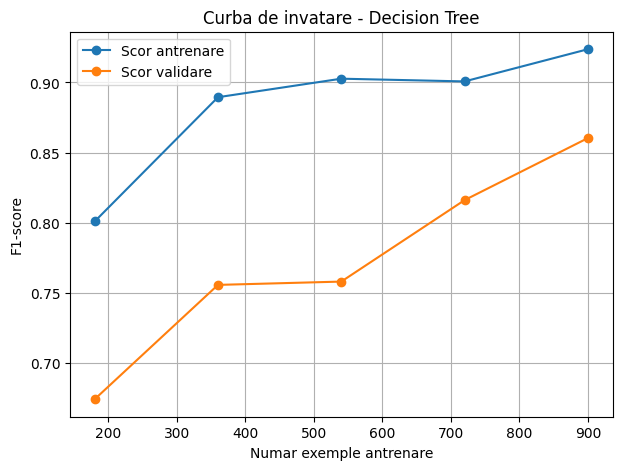

In [98]:
plot_learning_curve(best_dt_model, "Decision Tree", X_train, y_train, "../results/learning_curve_dt.png")

### Interpretarea curbei de învățare pentru Decision Tree

Curba de învățare pentru Decision Tree arată că scorul de antrenare este mai mare decât scorul de validare pentru toate dimensiunile setului de antrenare. Acest lucru indică faptul că modelul se potrivește mai bine pe datele de antrenare decât pe datele noi.

Pe măsură ce numărul de exemple de antrenare crește, scorul de validare crește treptat. Acest lucru arată că modelul beneficiază de mai multe date și reușește să generalizeze mai bine.

Totuși, diferența dintre scorul de antrenare și scorul de validare rămâne vizibilă, ceea ce sugerează un posibil overfitting. Modelul nu pare să fie în underfitting, deoarece scorurile nu sunt mici.

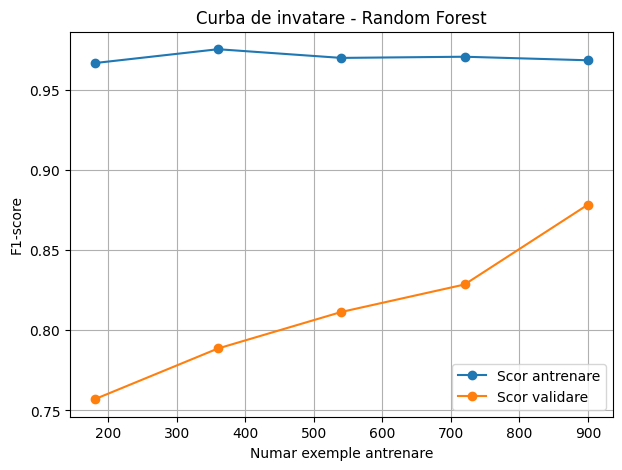

In [99]:
plot_learning_curve(best_rf_model, "Random Forest", X_train, y_train, "../results/learning_curve_rf.png")

### Interpretarea curbei de învățare pentru Random Forest

Curba de învățare pentru Random Forest arată că scorul de antrenare este foarte ridicat pentru toate dimensiunile setului de antrenare.

Scorul de validare crește treptat pe măsură ce numărul de exemple de antrenare crește, ceea ce indică faptul că modelul beneficiază de mai multe date și generalizează mai bine.

Totuși, diferența dintre scorul de antrenare și scorul de validare rămâne vizibilă, ceea ce sugerează un posibil overfitting.

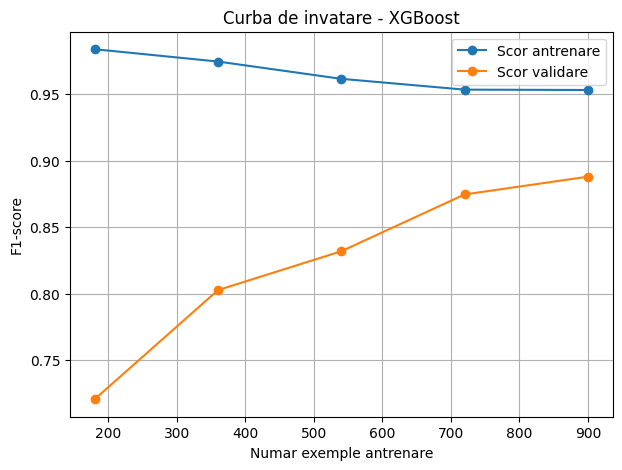

In [100]:
plot_learning_curve(best_xgb_model, "XGBoost", X_train, y_train, "../results/learning_curve_xgb.png")

### Interpretarea curbei de învățare pentru XGBoost

Curba de învățare pentru XGBoost arată că scorul de antrenare este ridicat pentru toate dimensiunile setului de antrenare. Scorul de validare crește constant pe măsură ce numărul de exemple de antrenare crește.

Diferența dintre scorul de antrenare și scorul de validare se reduce treptat, dar rămâne încă vizibilă. Prin urmare, poate exista un overfitting moderat, însă modelul nu prezintă underfitting, deoarece scorurile sunt ridicate.

Scorul de antrenare scade ușor pe măsură ce numărul de exemple crește, deoarece modelul trebuie să învețe dintr-un set de date mai mare și mai variat.

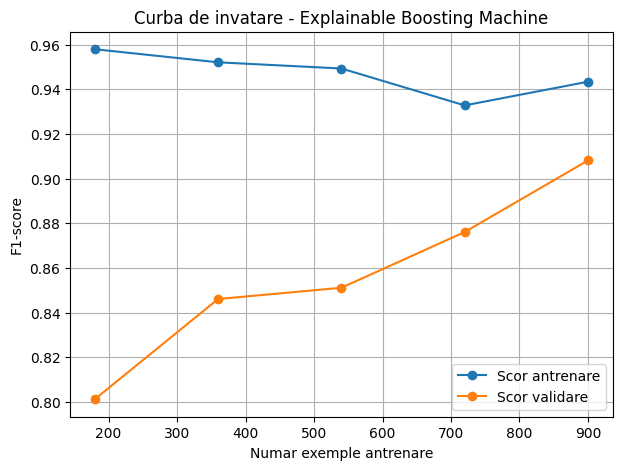

In [101]:
plot_learning_curve(best_ebm_model, "Explainable Boosting Machine", X_train, y_train, "../results/learning_curve_ebm.png")

### Interpretarea curbei de învățare pentru Explainable Boosting Machine

Curba de învățare pentru Explainable Boosting Machine arată că scorul de antrenare este ridicat pentru toate dimensiunile setului de antrenare, iar scorul de validare crește constant pe măsură ce numărul de exemple de antrenare crește.

Diferența dintre scorul de antrenare și scorul de validare se reduce treptat, iar la final cele două valori sunt mai apropiate decât în cazul unor modele anterioare. Acest lucru sugerează că modelul nu prezintă un overfitting puternic.

Modelul nu se află în underfitting, deoarece atât scorul de antrenare, cât și scorul de validare au valori ridicate.

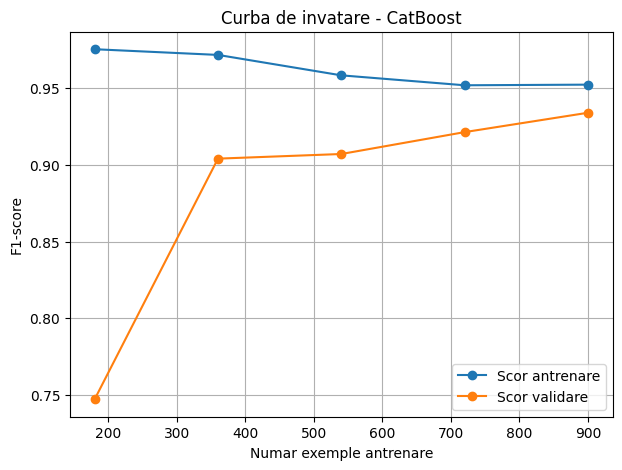

In [102]:
plot_learning_curve(best_cat_model, "CatBoost", X_train, y_train, "../results/learning_curve_cat.png")

### Interpretarea curbei de învățare pentru CatBoost

Curba de învățare pentru CatBoost arată, ca și în cazul celorlalte modele, că scorul de antrenare este ridicat pentru toate dimensiunile setului de antrenare, iar scorul de validare crește semnificativ pe măsură ce numărul de exemple de antrenare crește.

La final, diferența dintre scorul de antrenare și scorul de validare devine redusă, ceea ce sugerează că modelul nu prezintă un overfitting puternic.

Modelul nu este în underfitting, deoarece atât scorurile au valori ridicate. 

### Concluzie privind curbele de învățare

Curbele de învățare au fost analizate pentru cele 5 modele optimizate: Decision Tree, Random Forest, XGBoost, Explainable Boosting Machine și CatBoost.

Pentru toate modelele, scorul de validare crește pe măsură ce numărul de exemple de antrenare crește.

Modelele Decision Tree și Random Forest prezintă o diferență mai vizibilă între scorul de antrenare și scorul de validare.

La modelele XGBoost, Explainable Boosting Machine și CatBoost, diferența dintre scorul de antrenare și scorul de validare se reduce pe măsură ce crește numărul de exemple.

Dintre modelele analizate, CatBoost are una dintre cele mai bune curbe de învățare, deoarece scorul de validare ajunge la o valoare ridicată și se apropie de scorul de antrenare. Acest lucru susține alegerea modelului CatBoost optimizat ca model final pentru problema de clasificare.

## Explicabilitatea și analiza SHAP

În această etapă este analizată explicabilitatea modelelor folosind SHAP.

SHAP ajută la interpretarea predicțiilor unui model, arătând cât de mult contribuie fiecare caracteristică la rezultatul final.

Analiza va fi realizată pentru primele 3 modele optimizate:

1. CatBoost optimizat
2. Explainable Boosting Machine optimizat
3. XGBoost optimizat

Pentru fiecare model vor fi analizate influențele globale ale caracteristicilor, iar pentru modelul final va fi prezentată și o explicație locală pentru o predicție concretă.

In [74]:
explainer_cat = shap.TreeExplainer(best_cat_model)
shap_values_cat = explainer_cat.shap_values(X_test)

print("Dimensiune SHAP values:", shap_values_cat.shape)
print("Dimensiune X_test:", X_test.shape)

Dimensiune SHAP values: (375, 10)
Dimensiune X_test: (375, 10)


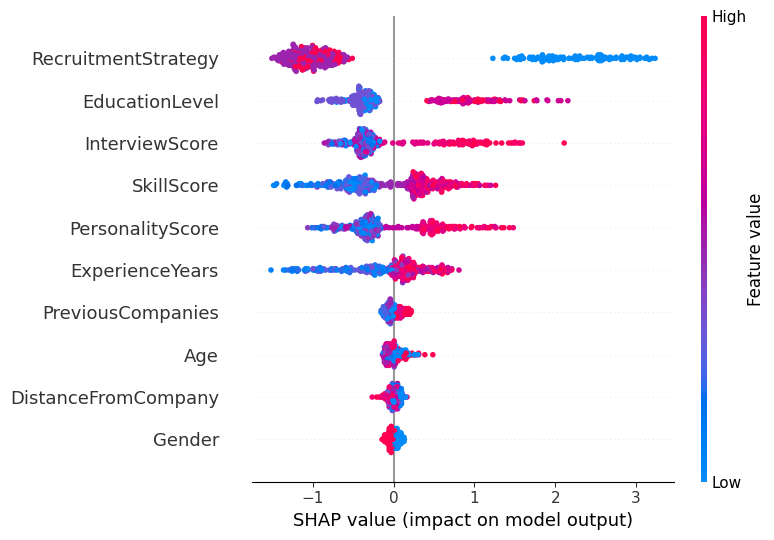

In [75]:
shap.summary_plot(shap_values_cat, X_test)

### Interpretarea SHAP summary plot pentru CatBoost

Graficul SHAP summary plot arată influența globală a caracteristicilor asupra predicțiilor modelului CatBoost.

Caracteristicile sunt ordonate după importanța lor, cele mai influente fiind afișate în partea de sus. În acest caz, cele mai importante caracteristici sunt 'RecruitmentStrategy', 'EducationLevel', 'InterviewScore', 'SkillScore' și 'PersonalityScore'.

Valorile SHAP pozitive împing predicția spre clasa '1', adică spre candidatul angajat, iar valorile SHAP negative împing predicția spre clasa '0', adică spre candidatul neangajat.

Pentru 'InterviewScore', 'SkillScore' și 'PersonalityScore', valorile mari tind să împingă predicția spre angajare, în timp ce valorile mici tind să împingă predicția spre neangajare.

Conform acestui grafic, primele 3 caracteristici importante pentru model sunt 'RecruitmentStrategy', 'EducationLevel' și 'InterviewScore'.

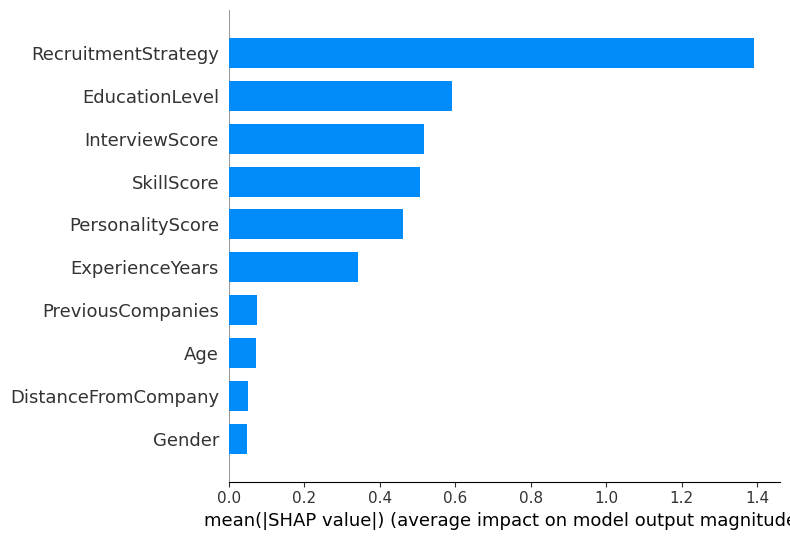

In [76]:
shap.summary_plot(shap_values_cat, X_test, plot_type="bar")

### Interpretarea SHAP bar plot pentru CatBoost

Graficul SHAP bar plot arată importanța medie a caracteristicilor pentru modelul CatBoost. Caracteristicile cu valori mai mari ale mediei valorilor SHAP au o influență mai mare asupra predicțiilor modelului.

Conform graficului, cea mai importantă caracteristică este 'RecruitmentStrategy', având o influență semnificativ mai mare decât celelalte variabile.

Caracteristicile 'Gender', 'DistanceFromCompany', 'Age' și 'PreviousCompanies' au o influență mult mai redusă asupra predicțiilor modelului.

In [77]:
explainer_xgb = shap.TreeExplainer(best_xgb_model)
shap_values_xgb = explainer_xgb.shap_values(X_test)

print("Dimensiune SHAP values XGBoost:", shap_values_xgb.shape)
print("Dimensiune X_test:", X_test.shape)

Dimensiune SHAP values XGBoost: (375, 10)
Dimensiune X_test: (375, 10)


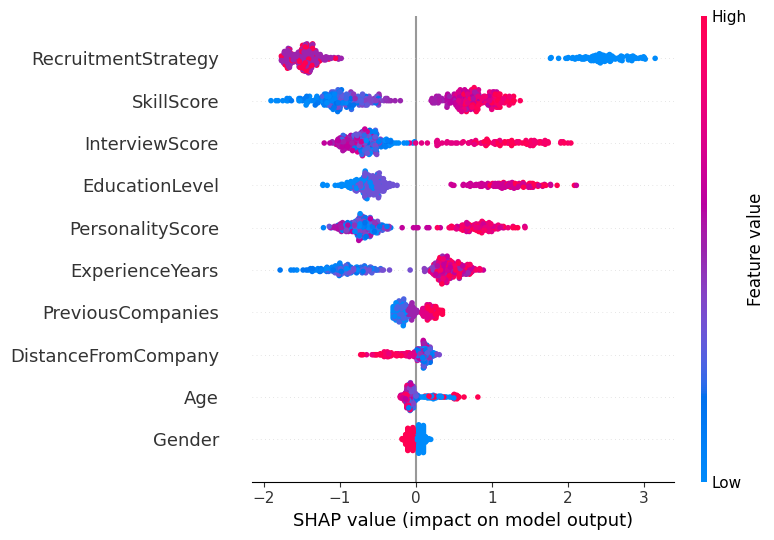

In [78]:
shap.summary_plot(shap_values_xgb, X_test)

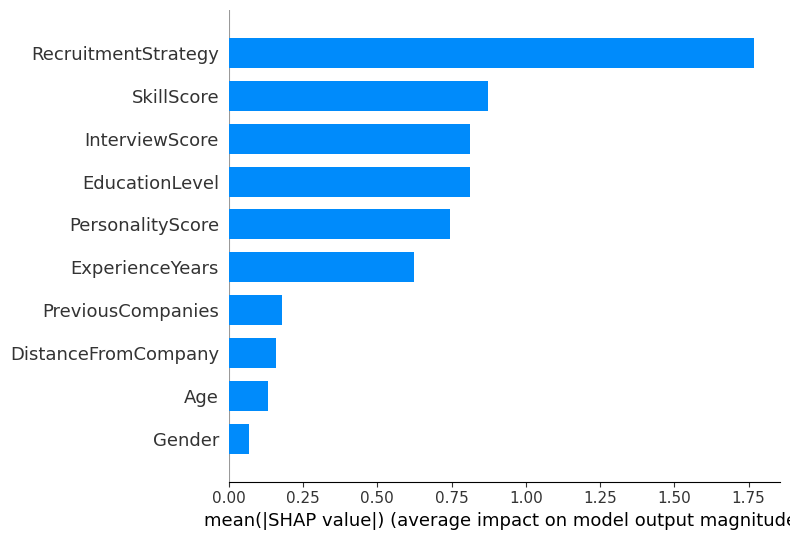

In [79]:
shap.summary_plot(shap_values_xgb, X_test, plot_type="bar")

### Interpretarea graficelor SHAP pentru XGBoost

Graficele SHAP pentru XGBoost arată că modelul folosește caracteristici asemănătoare cu modelul CatBoost pentru realizarea predicțiilor.

Cea mai importantă caracteristică este 'RecruitmentStrategy', urmată de 'SkillScore', 'InterviewScore', 'EducationLevel' și 'PersonalityScore'.

Față de CatBoost, XGBoost acordă o importanță mai mare caracteristicii 'SkillScore', care apare pe poziția a doua în clasamentul importanței caracteristicilor. Totuși, caracteristicile principale rămân similare, ceea ce arată că ambele modele au identificat factori relevanți asemănători pentru decizia de angajare.

In [80]:
explainer_ebm = shap.Explainer(best_ebm_model.predict_proba, X_train)
shap_values_ebm = explainer_ebm(X_test)

print("Dimensiune SHAP values EBM:", shap_values_ebm.values.shape)
print("Dimensiune X_test:", X_test.shape)

ExactExplainer explainer: 376it [01:11,  5.26it/s]                         

Dimensiune SHAP values EBM: (375, 10, 2)
Dimensiune X_test: (375, 10)


In [81]:
shap_values_ebm_class1 = shap_values_ebm.values[:, :, 1]
print("Dimensiune SHAP EBM pentru clasa 1:", shap_values_ebm_class1.shape)

Dimensiune SHAP EBM pentru clasa 1: (375, 10)


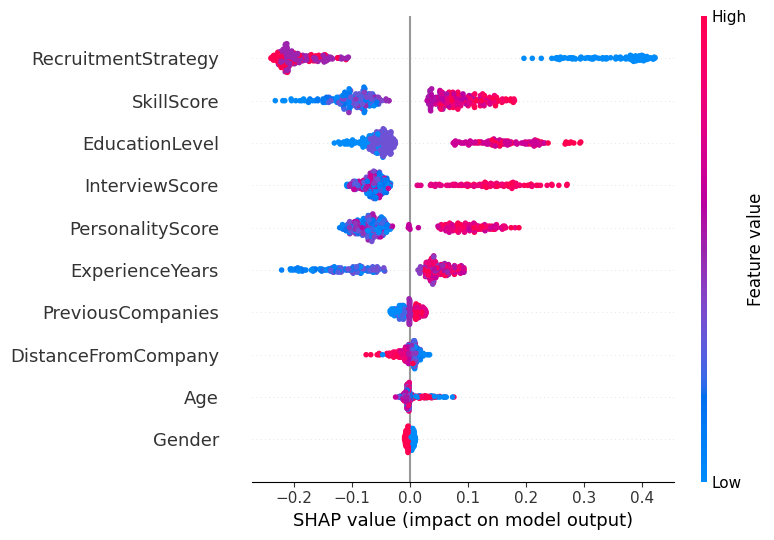

In [82]:
shap.summary_plot(shap_values_ebm_class1, X_test)

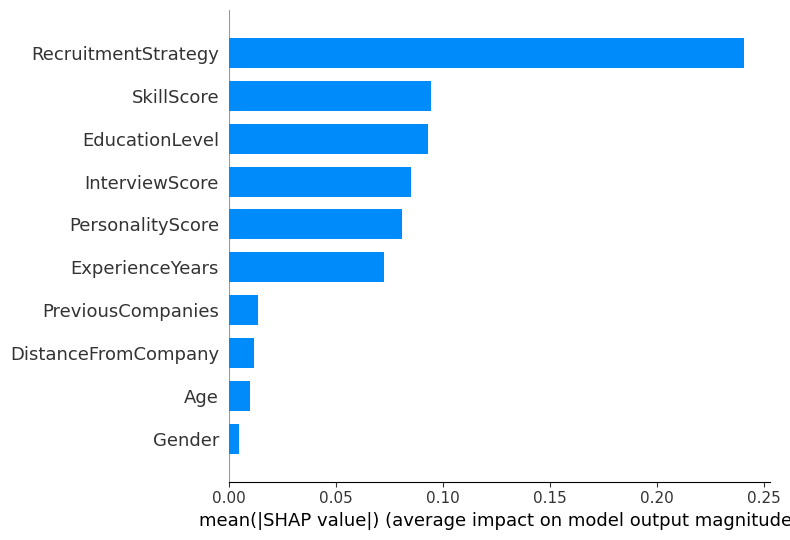

In [83]:
shap.summary_plot(shap_values_ebm_class1, X_test, plot_type="bar")

### Interpretarea graficelor SHAP pentru Explainable Boosting Machine

Graficele SHAP pentru Explainable Boosting Machine arată că modelul acordă cea mai mare importanță caracteristicii 'RecruitmentStrategy'.

Următoarele caracteristici importante sunt 'SkillScore', 'EducationLevel', 'InterviewScore', 'PersonalityScore' și 'ExperienceYears'.

În summary plot se observă că valorile mari pentru 'SkillScore', 'EducationLevel', 'InterviewScore', 'PersonalityScore' și 'ExperienceYears' tind să împingă predicția spre clasa '1', adică spre candidatul angajat.

Bar plot-ul confirmă importanța globală a caracteristicilor și arată că primele 3 caracteristici pentru EBM sunt 'RecruitmentStrategy', 'SkillScore' și 'EducationLevel'.

In [84]:
example_index = 0

example_data = X_test.iloc[[example_index]]
example_prediction = best_cat_model.predict(example_data)[0]
example_probability = best_cat_model.predict_proba(example_data)[0, 1]

print("Datele candidatului analizat:")
display(example_data)
print("Predictie model:", example_prediction)
print("Probabilitate pentru clasa 1:", example_probability)

Datele candidatului analizat:


,Age,Gender,EducationLevel,ExperienceYears,PreviousCompanies,DistanceFromCompany,InterviewScore,SkillScore,PersonalityScore,RecruitmentStrategy
1096,25,1,2,7,5,12.878001,77,89,38,2


Predictie model: 0
Probabilitate pentru clasa 1: 0.045688433266284086


### Exemplu local analizat

Pentru explicația locală a fost ales primul candidat din setul de testare.

Modelul CatBoost optimizat a prezis clasa '0', adică acest candidat este clasificat ca neangajat. Probabilitatea estimată pentru clasa '1', adică pentru angajare, este de aproximativ 0.045.

În continuare, se folosesc graficele SHAP pentru a observa ce caracteristici au contribuit cel mai mult la această predicție.

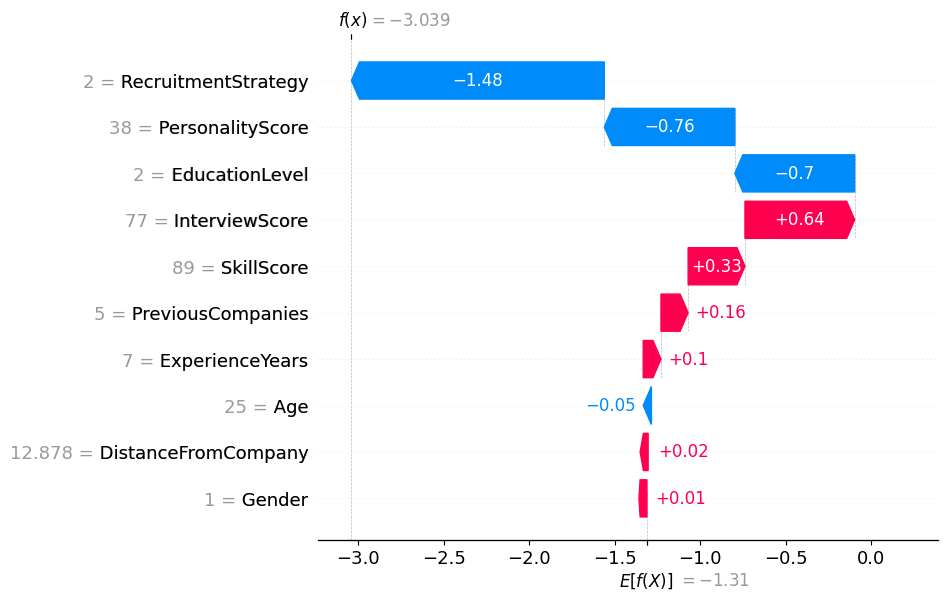

In [85]:
example_shap_values = shap_values_cat[example_index]
example_base_value = explainer_cat.expected_value

shap_explanation_cat = shap.Explanation(
    values=example_shap_values,
    base_values=example_base_value,
    data=X_test.iloc[example_index],
    feature_names=X_test.columns
)

shap.plots.waterfall(shap_explanation_cat)

### Interpretarea waterfall plot pentru CatBoost

Waterfall plot-ul explică predicția modelului CatBoost pentru candidatul ales din setul de testare. Modelul pornește de la valoarea medie a predicției, notată cu E[f(X)], iar fiecare caracteristică modifică această valoare în sus sau în jos.

Valorile pozitive împing predicția spre clasa '1', adică spre candidatul angajat, iar valorile negative împing predicția spre clasa '0', adică spre candidatul neangajat.

Pentru acest candidat, modelul a prezis clasa '0', cu o probabilitate mică pentru angajare. Caracteristicile care au contribuit cel mai mult la această decizie au fost 'RecruitmentStrategy' = 2, 'PersonalityScore' = 38 și 'EducationLevel' = 2, care au împins predicția spre neangajare.

În schimb, 'InterviewScore' = 77 și 'SkillScore' = 89 au avut o influență pozitivă și au împins predicția spre angajare. Totuși, influența pozitivă a acestora nu a fost suficientă pentru a schimba decizia finală a modelului.

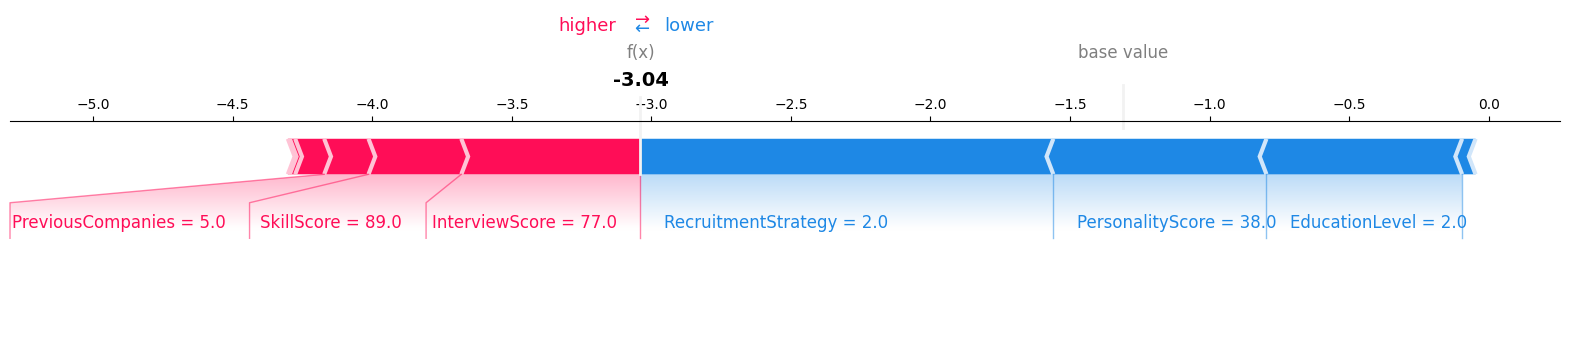

In [86]:
shap.initjs()

shap.force_plot(
    explainer_cat.expected_value,
    shap_values_cat[example_index],
    X_test.iloc[example_index],
    matplotlib=True
)

### Interpretare force plot pentru CatBoost

Force plot-ul prezintă contribuția caracteristicilor pentru aceeași predicție locală analizată anterior.

În acest caz, valoarea finală a predicției este aproximativ -3.04, ceea ce corespunde unei probabilități reduse pentru clasa '1'. Prin urmare, modelul clasifică acest candidat ca neangajat.

Caracteristicile marcate cu roșu au împins predicția spre clasa '1', adică spre angajare. În schimb, caracteristicile marcate cu albastru au avut o influență mai puternică în sens opus și au împins predicția spre clasa '0'.

Astfel, deși unele scoruri ale candidatului au avut efect pozitiv, contribuțiile negative au fost mai puternice, iar decizia finală a modelului a fost neangajarea.

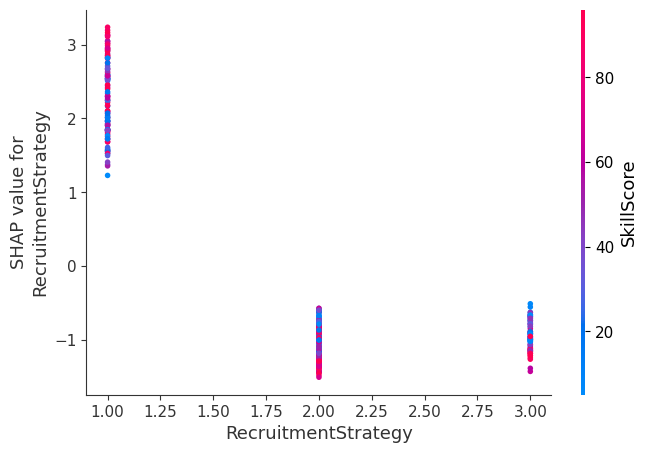

In [87]:
shap.dependence_plot("RecruitmentStrategy", shap_values_cat, X_test)

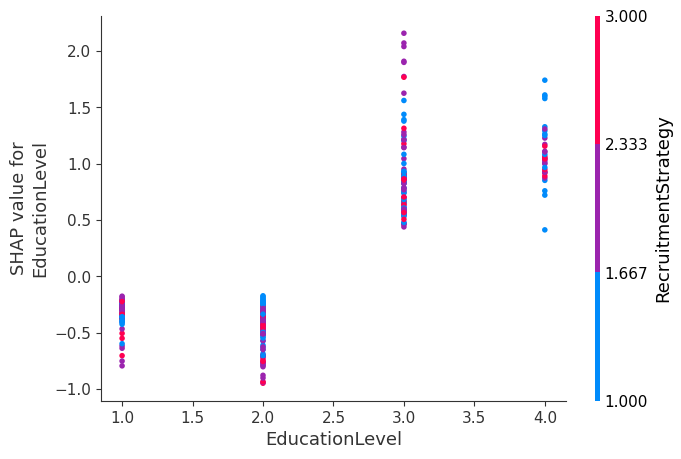

In [88]:
shap.dependence_plot("EducationLevel", shap_values_cat, X_test)

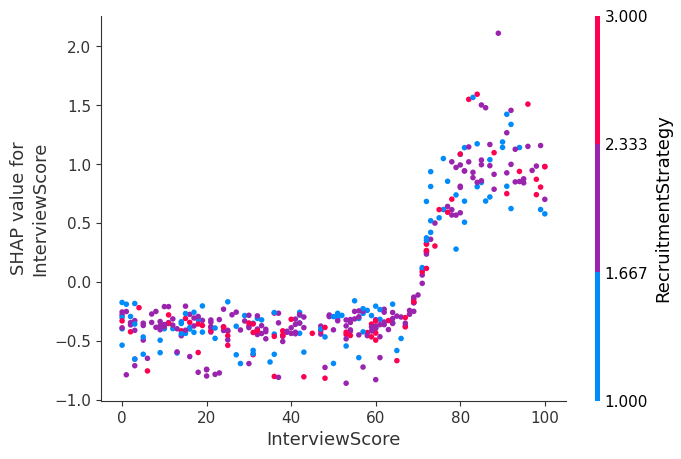

In [89]:
shap.dependence_plot("InterviewScore", shap_values_cat, X_test)

### Interpretare SHAP scatter plot pentru CatBoost

Scatter plot-urile SHAP au fost realizate pentru cele mai importante 3 caracteristici ale modelului CatBoost: 'RecruitmentStrategy', 'EducationLevel' și 'InterviewScore'.

Pentru 'RecruitmentStrategy', se observă că valoarea '1' are valori SHAP pozitive mari, ceea ce înseamnă că împinge predicția spre clasa '1'. Valorile '2' și '3' au valori SHAP negative, deci împing predicția spre clasa '0'.

Pentru 'EducationLevel', valorile mai mici, precum '1' și '2', au în general valori SHAP negative, ceea ce indică o influență spre neangajare. Valorile mai mari au valori SHAP pozitive, deci cresc probabilitatea ca modelul să prezică angajarea.

Pentru 'InterviewScore', se observă că scorurile mai mici au valori SHAP negative, iar scorurile mari, în special peste arpximativ 70, au valori SHAP pozitive. Acest lucru arată că un scor mai bun la interviu influențează predicția în direcția angajării.

Culoarea punctelor indică o altă caracteristică folosită de SHAP pentru a evidenția posibile interacțiuni între variabile. În ansamblu, aceste grafice arată că modelul CatBoost folosește logic caracteristicile importante.

### Concluzie privind analiza SHAP

Analiza SHAP a evidențiat faptul că modelele optimizate folosesc caracteristici asemănătoare pentru realizarea predicțiilor. Pentru modelul final CatBoost, cele mai importante caracteristici sunt 'RecruitmentStrategy', 'EducationLevel' și 'InterviewScore'.

Valorile SHAP au arătat că anumite valori ale acestor caracteristici împing predicția spre clasa '1', adică spre angajare, în timp ce alte valori împing predicția spre clasa '0', adică spre neangajare.

Explicația locală pentru candidatul analizat a arătat concret cum fiecare caracteristică a contribuit la decizia modelului. Chiar dacă unele variabile au avut o influență pozitivă, caracteristicile cu influență negativă au fost mai puternice, iar modelul a prezis clasa '0'.

Prin urmare, analiza SHAP confirmă faptul că modelul CatBoost nu oferă doar performanță bună, ci permite și interpretarea factorilor care influențează predicțiile.

In [90]:
import os
import joblib

os.makedirs("../models", exist_ok=True)

joblib.dump(best_dt_model, "../models/decision_tree_model.pkl")
joblib.dump(best_rf_model, "../models/random_forest_model.pkl")
joblib.dump(best_xgb_model, "../models/xgboost_model.pkl")
joblib.dump(best_ebm_model, "../models/ebm_model.pkl")
joblib.dump(best_cat_model, "../models/catboost_model.pkl")

['../models/catboost_model.pkl']

In [91]:
os.makedirs("../results", exist_ok=True)

h_results_sorted.to_csv("../results/tuned_models_results.csv", index=False)